# QSVM Experiment 10: selection-aware null testStandalone notebook, self-contained: does not require running the full Step-4diagnostics notebook first. It rebuilds only the representations item 10 actuallyneeds, runs a proper (honest, nested) classical CV once to get both the realbalanced accuracy and the hyperparameters the procedure genuinely selects, and thenuses those as the fixed hyperparameters for the permutation loop.**What item 10 asks for.** Permute the class labels and rerun the representation andhyperparameter selection procedure, to calibrate how large an apparent winner canlook purely by chance. Doing the full nested search on every one of 1000 permutationswould be far too expensive, so the standard efficient design is used instead: the realnested CV is run once (honestly, with its own inner-loop hyperparameter search) to getthe modal hyperparameters per representation and kernel, and the permutation loop thenreuses those fixed hyperparameters with a single fast group-aware CV pass perpermutation. The rigor of a permutation test comes from comparing against manypermutations under an identical pipeline, not from re-optimising hyperparametersinside each one.**Representations compared against `mean_z`:** `comp_freq_20`, five independentlyseeded random projections (`rand_proj_1`...`rand_proj_5`, per Steve's explicit requestfor repeated random projections), `pca_5` (fold-safe PCA), and `full45` (theunreduced reference).**Scope.** Classical kernels only, consistent with the rest of the Step-4 diagnostics.

## 1. Configuration and imports

In [1]:
import os
import time
import itertools
import numpy as np
import pandas as pd
from scipy import stats
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, StratifiedGroupKFold
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score, accuracy_score, matthews_corrcoef
from sklearn.metrics.pairwise import rbf_kernel, linear_kernel, polynomial_kernel

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N_SPLITS_OUTER, N_REPEATS_OUTER, N_SPLITS_INNER = 5, 20, 4
CLASSICAL_GRIDS = {
    'linear': {'C': [0.1, 1, 10]},
    'rbf':    {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1, 1]},
    'poly':   {'C': [0.1, 1, 10], 'degree': [2, 3], 'gamma': ['scale', 0.1, 1], 'coef0': [0.0, 1.0]},
}
MODELS = ['linear', 'rbf', 'poly']
N_PERMUTATIONS = 1000

OUTDIR = 'results_experiment10'
os.makedirs(OUTDIR, exist_ok=True)
print(f'outer {N_SPLITS_OUTER}x{N_REPEATS_OUTER} = {N_SPLITS_OUTER*N_REPEATS_OUTER} folds, inner {N_SPLITS_INNER}')
print(f'{N_PERMUTATIONS} permutations planned')

outer 5x20 = 100 folds, inner 4
1000 permutations planned


## 2. Data, sequences, groups

In [2]:
_lab = pd.read_excel('Docking_high_low_energy_labels.xlsx', sheet_name='Results')
_lab = _lab.dropna(subset=['Sequence Epitope)']).reset_index(drop=True)
sequences = _lab['Sequence Epitope)'].astype(str).str.strip().tolist()
y = (_lab['Otsu Class theshold -77.8'] == 'Strong').astype(int).values

full45 = pd.read_csv('zscaled_5_45.csv', index_col=0).values
assert full45.shape == (len(y), 45)
print(f'{len(y)} peptides, class balance {np.bincount(y)}')

  warn("""Cannot parse header or footer so it will be ignored""")
80 peptides, class balance [42 38]


In [3]:
K_SHARED, IDENTITY_THRESH = 5, 7 / 9


def similarity_edges(sequences, k_shared=K_SHARED, identity_thresh=IDENTITY_THRESH):
    n, L = len(sequences), len(sequences[0])
    kmers = [{s[i:i + k_shared] for i in range(L - k_shared + 1)} for s in sequences]
    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            shared = bool(kmers[i] & kmers[j])
            identity = sum(a == b for a, b in zip(sequences[i], sequences[j])) / L
            if shared or identity >= identity_thresh:
                edges.append((i, j))
    return edges


def build_groups_unionfind(n, edges):
    parent = list(range(n))

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a

    for i, j in edges:
        ri, rj = find(i), find(j)
        if ri != rj:
            parent[ri] = rj
    raw = [find(i) for i in range(n)]
    remap = {g: k for k, g in enumerate(sorted(set(raw)))}
    return np.array([remap[g] for g in raw])


n_pep = len(sequences)
edges = similarity_edges(sequences)
groups = build_groups_unionfind(n_pep, edges)

adj = coo_matrix((np.ones(len(edges)),
                  (np.array([e[0] for e in edges]), np.array([e[1] for e in edges]))),
                 shape=(n_pep, n_pep))
n_cc, cc_labels = connected_components(adj, directed=False)
assert len(set(zip(groups, cc_labels))) == len(set(groups)) == len(set(cc_labels))
print(f'{len(np.unique(groups))} groups (verified against scipy), '
      f'{pd.Series(groups).value_counts().eq(1).sum()} singletons')

43 groups (verified against scipy), 25 singletons


## 3. The representations compared against `mean_z`

In [4]:
def mean_from_full45(X45, exclude_positions=()):
    keep = [p for p in range(9) if p not in exclude_positions]
    out = np.zeros((X45.shape[0], 5))
    for k in range(5):
        cols = [p * 5 + k for p in keep]
        out[:, k] = X45[:, cols].mean(axis=1)
    return out


mean_z = mean_from_full45(full45)

AAS = sorted(set(''.join(sequences)))
comp_freq_20 = np.zeros((n_pep, len(AAS)))
for i, s in enumerate(sequences):
    for a in s:
        comp_freq_20[i, AAS.index(a)] += 1
comp_freq_20 /= len(sequences[0])


def make_random_projection(n_features_in, n_out=5, seed=2026):
    rng = np.random.default_rng(seed)
    return rng.normal(size=(n_features_in, n_out)) / np.sqrt(n_features_in)


N_RAND_PROJECTIONS = 5
RAND_SEEDS = {i: 2025 + i for i in range(1, N_RAND_PROJECTIONS + 1)}
RAND_Rs = {i: make_random_projection(45, 5, seed=RAND_SEEDS[i]) for i in RAND_SEEDS}
RAND_PROJ_NAMES = [f'rand_proj_{i}' for i in range(1, N_RAND_PROJECTIONS + 1)]
print('random projection seeds:', RAND_SEEDS)


def fit_scale(X_train, X_test):
    scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
    scaler.fit(X_train)
    return scaler.transform(X_train), scaler.transform(X_test)


def transform_random_projection(X_train, X_test, R):
    mu, sd = X_train.mean(0), X_train.std(0)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return ((X_train - mu) / sd) @ R, ((X_test - mu) / sd) @ R


def transform_pca(X_train, X_test, n_components=5):
    scaler = StandardScaler().fit(X_train)
    pca = PCA(n_components=n_components, random_state=RANDOM_SEED).fit(scaler.transform(X_train))
    return pca.transform(scaler.transform(X_train)), pca.transform(scaler.transform(X_test))


def _transform(rep, tr_idx, te_idx):
    if callable(rep):
        return rep(tr_idx, te_idx)
    return fit_scale(rep[tr_idx], rep[te_idx])


REPS = {'mean_z': mean_z, 'comp_freq_20': comp_freq_20, 'full45': full45,
       'pca_5': lambda tr, te: transform_pca(full45[tr], full45[te], n_components=5)}
for i, R in RAND_Rs.items():
    REPS[f'rand_proj_{i}'] = (lambda tr, te, R=R: transform_random_projection(full45[tr], full45[te], R))

ALL_REP_NAMES = ['mean_z', 'comp_freq_20'] + RAND_PROJ_NAMES + ['pca_5', 'full45']
print(f'{len(ALL_REP_NAMES)} representations:', ALL_REP_NAMES)

random projection seeds: {1: 2026, 2: 2027, 3: 2028, 4: 2029, 5: 2030}
9 representations: ['mean_z', 'comp_freq_20', 'rand_proj_1', 'rand_proj_2', 'rand_proj_3', 'rand_proj_4', 'rand_proj_5', 'pca_5', 'full45']


## 4. Honest nested CV (run once, needed for both the real numbers and the modalhyperparameters used later in the permutation loop)

In [5]:
def make_outer_splits(y, groups=None, n_splits=N_SPLITS_OUTER, n_repeats=N_REPEATS_OUTER,
                      random_state=RANDOM_SEED):
    if groups is None:
        return list(RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats,
                                            random_state=random_state).split(np.zeros(len(y)), y))
    splits = []
    for r in range(n_repeats):
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state + r)
        splits.extend(sgkf.split(np.zeros(len(y)), y, groups))
    return splits


def _inner_splits(y_tr, groups_tr, fold_i):
    if groups_tr is None:
        return list(StratifiedKFold(n_splits=N_SPLITS_INNER, shuffle=True,
                                    random_state=RANDOM_SEED + fold_i).split(np.zeros(len(y_tr)), y_tr))
    return list(StratifiedGroupKFold(n_splits=N_SPLITS_INNER, shuffle=True,
                                     random_state=RANDOM_SEED + fold_i)
                .split(np.zeros(len(y_tr)), y_tr, groups_tr))


def _param_combinations(grid):
    keys = list(grid)
    return [dict(zip(keys, vals)) for vals in itertools.product(*(grid[k] for k in keys))]


def _resolve_gamma(gamma, Xs):
    if gamma == 'scale':
        return 1.0 / (Xs.shape[1] * Xs.var()) if Xs.var() > 0 else 1.0
    return gamma


def _fit_svc(kernel_name, Xtr, ytr, params):
    gamma = _resolve_gamma(params.get('gamma', 'scale'), Xtr)
    if kernel_name == 'linear':
        clf = SVC(kernel='linear', C=params['C'])
    elif kernel_name == 'rbf':
        clf = SVC(kernel='rbf', C=params['C'], gamma=gamma)
    else:
        clf = SVC(kernel='poly', C=params['C'], degree=params['degree'], gamma=gamma, coef0=params['coef0'])
    return clf.fit(Xtr, ytr)


def nested_cv_classical(rep, y, kernel_name, groups=None, n_repeats_outer=N_REPEATS_OUTER):
    combos = _param_combinations(CLASSICAL_GRIDS[kernel_name])
    outer = make_outer_splits(y, groups, n_repeats=n_repeats_outer)
    rows, predictions = [], {}

    for fold_i, (tr_idx, te_idx) in enumerate(outer):
        y_tr, y_te = y[tr_idx], y[te_idx]
        inner = _inner_splits(y_tr, None if groups is None else groups[tr_idx], fold_i)

        inner_scores = {}
        for in_tr, in_val in inner:
            abs_tr, abs_val = tr_idx[in_tr], tr_idx[in_val]
            Xi_tr, Xi_val = _transform(rep, abs_tr, abs_val)
            for ci, params in enumerate(combos):
                clf = _fit_svc(kernel_name, Xi_tr, y[abs_tr], params)
                s = balanced_accuracy_score(y[abs_val], clf.predict(Xi_val))
                inner_scores.setdefault(ci, []).append(s)

        best_ci = max(inner_scores, key=lambda k: np.mean(inner_scores[k]))
        best_params = combos[best_ci]

        Xtr, Xte = _transform(rep, tr_idx, te_idx)
        clf = _fit_svc(kernel_name, Xtr, y_tr, best_params)
        y_pred = clf.predict(Xte)

        row = {'fold': fold_i, 'balanced_accuracy': balanced_accuracy_score(y_te, y_pred),
               'n_train': len(tr_idx), 'n_test': len(te_idx)}
        row.update({f'best_{k}': v for k, v in best_params.items()})
        rows.append(row)
        predictions[fold_i] = {'test_idx': te_idx.tolist(), 'y_true': y_te.tolist(), 'y_pred': y_pred.tolist()}
    return pd.DataFrame(rows), predictions

In [6]:
t0 = time.time()
honest_results = {}
for rep_name in ALL_REP_NAMES:
    honest_results[rep_name] = {}
    for kn in MODELS:
        res, preds = nested_cv_classical(REPS[rep_name], y, kn, groups=groups)
        honest_results[rep_name][kn] = (res, preds)
    print(f'  {rep_name}: {time.time()-t0:.0f}s elapsed')
print(f'Honest nested CV total: {time.time()-t0:.0f}s')

tab = pd.DataFrame({rep_name: {kn: honest_results[rep_name][kn][0]['balanced_accuracy'].mean()
                               for kn in MODELS}
                    for rep_name in ALL_REP_NAMES}).T
tab.to_csv(f'{OUTDIR}/exp10_honest_balanced_accuracy.csv')
display(tab)

  mean_z: 35s elapsed
  comp_freq_20: 66s elapsed
  rand_proj_1: 99s elapsed
  rand_proj_2: 134s elapsed
  rand_proj_3: 167s elapsed
  rand_proj_4: 200s elapsed
  rand_proj_5: 233s elapsed
  pca_5: 287s elapsed
  full45: 318s elapsed
Honest nested CV total: 318s
                linear       rbf      poly
mean_z        0.831438  0.819970  0.839841
comp_freq_20  0.767192  0.793323  0.797917
rand_proj_1   0.603105  0.681488  0.682460
rand_proj_2   0.493631  0.500933  0.524335
rand_proj_3   0.597540  0.612827  0.592093
rand_proj_4   0.569970  0.709752  0.591131
rand_proj_5   0.574216  0.610417  0.581558
pca_5         0.614048  0.592490  0.571171
full45        0.783998  0.807937  0.775198


In [7]:
def extract_modal_params(res_by_model):
    out = {}
    for kn, (res, preds) in res_by_model.items():
        if kn == 'linear':
            out[kn] = {'C': res['best_C'].mode()[0]}
        elif kn == 'rbf':
            out[kn] = {'C': res['best_C'].mode()[0], 'gamma': res['best_gamma'].mode()[0]}
        else:
            out[kn] = {'C': res['best_C'].mode()[0], 'gamma': res['best_gamma'].mode()[0],
                      'degree': res['best_degree'].mode()[0], 'coef0': res['best_coef0'].mode()[0]}
    return out


modal_params = {rep_name: extract_modal_params(honest_results[rep_name]) for rep_name in ALL_REP_NAMES}
for rep_name, by_kernel in modal_params.items():
    print(f'{rep_name:14s}', by_kernel)

mean_z         {'linear': {'C': np.float64(1.0)}, 'rbf': {'C': np.int64(10), 'gamma': 0.01}, 'poly': {'C': np.float64(1.0), 'gamma': 'scale', 'degree': np.int64(2), 'coef0': np.float64(1.0)}}
comp_freq_20   {'linear': {'C': np.float64(0.1)}, 'rbf': {'C': np.int64(10), 'gamma': 'scale'}, 'poly': {'C': np.float64(0.1), 'gamma': 'scale', 'degree': np.int64(3), 'coef0': np.float64(1.0)}}
rand_proj_1    {'linear': {'C': np.float64(0.1)}, 'rbf': {'C': np.int64(10), 'gamma': 0.1}, 'poly': {'C': np.float64(1.0), 'gamma': 1, 'degree': np.int64(2), 'coef0': np.float64(1.0)}}
rand_proj_2    {'linear': {'C': np.float64(0.1)}, 'rbf': {'C': np.float64(10.0), 'gamma': 'scale'}, 'poly': {'C': np.float64(1.0), 'gamma': 1, 'degree': np.int64(2), 'coef0': np.float64(0.0)}}
rand_proj_3    {'linear': {'C': np.float64(0.1)}, 'rbf': {'C': np.int64(1), 'gamma': 0.1}, 'poly': {'C': np.float64(0.1), 'gamma': 'scale', 'degree': np.int64(2), 'coef0': np.float64(1.0)}}
rand_proj_4    {'linear': {'C': np.float64(0.

## 5. The permutation loop

In [8]:
def _fit_svc_fixed(kernel_name, Xtr, ytr, params):
    if kernel_name == 'linear':
        return SVC(kernel='linear', C=params['C']).fit(Xtr, ytr)
    gamma = params['gamma']
    if gamma == 'scale':
        gamma = 1.0 / (Xtr.shape[1] * Xtr.var()) if Xtr.var() > 0 else 1.0
    if kernel_name == 'rbf':
        return SVC(kernel='rbf', C=params['C'], gamma=gamma).fit(Xtr, ytr)
    return SVC(kernel='poly', C=params['C'], degree=params['degree'], gamma=gamma,
              coef0=params['coef0']).fit(Xtr, ytr)


def quick_cv_score(X, y_perm, groups, kernel_name, params, n_splits=5, seed=0):
    skf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = []
    for tr, te in skf.split(np.zeros(len(y_perm)), y_perm, groups):
        Xtr, Xte = fit_scale(X[tr], X[te])
        clf = _fit_svc_fixed(kernel_name, Xtr, y_perm[tr], params)
        scores.append(balanced_accuracy_score(y_perm[te], clf.predict(Xte)))
    return np.mean(scores)


def null_representations(full45_local, comp_freq_20_local, mean_z_local, Rs, seed_for_pca=RANDOM_SEED):
    out = {'mean_z': mean_z_local, 'comp_freq_20': comp_freq_20_local, 'full45': full45_local}
    for rp_name, R in Rs.items():
        out[rp_name] = ((full45_local - full45_local.mean(0)) / full45_local.std(0)) @ R
    out['pca_5'] = PCA(n_components=5, random_state=seed_for_pca).fit_transform(
        StandardScaler().fit_transform(full45_local))
    return out


RAND_Rs_by_name = {f'rand_proj_{i}': R for i, R in RAND_Rs.items()}
NULL_REPS = [r for r in ALL_REP_NAMES if r != 'mean_z']

In [9]:
rng_perm = np.random.default_rng(RANDOM_SEED)
null_gaps = {kn: {rep: [] for rep in NULL_REPS} for kn in MODELS}

t0 = time.time()
for p in range(N_PERMUTATIONS):
    y_perm = rng_perm.permutation(y)
    null_reps_p = null_representations(full45, comp_freq_20, mean_z, RAND_Rs_by_name,
                                       seed_for_pca=RANDOM_SEED)
    scores_p = {}
    for rep_name in ALL_REP_NAMES:
        for kn in MODELS:
            scores_p[(rep_name, kn)] = quick_cv_score(
                null_reps_p[rep_name], y_perm, groups, kn, modal_params[rep_name][kn], seed=p)
    for kn in MODELS:
        for rep_name in NULL_REPS:
            null_gaps[kn][rep_name].append(scores_p[('mean_z', kn)] - scores_p[(rep_name, kn)])
    if (p + 1) % 200 == 0:
        print(f'  {p+1}/{N_PERMUTATIONS} permutations, {time.time()-t0:.0f}s')

print(f'Null test: {time.time()-t0:.0f}s total for {N_PERMUTATIONS} permutations, '
      f'{len(NULL_REPS)} representations x {len(MODELS)} kernels')

  200/1000 permutations, 126s
  400/1000 permutations, 255s
  600/1000 permutations, 384s
  800/1000 permutations, 511s
  1000/1000 permutations, 636s
Null test: 636s total for 1000 permutations, 8 representations x 3 kernels


## 6. Results

In [10]:
observed_gaps = {}
for kn in MODELS:
    for rep_name in NULL_REPS:
        observed_gaps[(kn, rep_name)] = tab.loc['mean_z', kn] - tab.loc[rep_name, kn]

rows = []
for kn in MODELS:
    for rep_name in NULL_REPS:
        null = np.array(null_gaps[kn][rep_name])
        obs = observed_gaps[(kn, rep_name)]
        p_emp = (null >= obs).mean()
        rows.append({'kernel': kn, 'vs': rep_name, 'observed_gap': obs,
                    'null_mean': null.mean(), 'null_std': null.std(),
                    'null_97.5pct': np.percentile(null, 97.5),
                    'empirical_p_one_sided': p_emp})

null_summary = pd.DataFrame(rows).set_index(['kernel', 'vs'])
null_summary.to_csv(f'{OUTDIR}/exp10_null_test.csv')
display(null_summary)

                     observed_gap  null_mean  null_std  null_97.5pct  empirical_p_one_sided
kernel vs                                                                                  
linear comp_freq_20      0.064246  -0.000584  0.081556      0.155366                  0.211
       rand_proj_1       0.228333  -0.004013  0.094071      0.184834                  0.004
       rand_proj_2       0.337808  -0.000869  0.095215      0.179177                  0.000
       rand_proj_3       0.233899   0.000426  0.089526      0.172886                  0.005
       rand_proj_4       0.261468  -0.000629  0.094501      0.182345                  0.002
       rand_proj_5       0.257222   0.002044  0.093925      0.185502                  0.003
       pca_5             0.217391   0.001082  0.093043      0.184486                  0.012
       full45            0.047440   0.001828  0.088797      0.170166                  0.320
rbf    comp_freq_20      0.026647   0.001906  0.082201      0.160724            

In [11]:
pooled_rows = []
for kn in MODELS:
    pooled_null = np.concatenate([null_gaps[kn][rp] for rp in RAND_PROJ_NAMES])
    pooled_obs_mean = np.mean([observed_gaps[(kn, rp)] for rp in RAND_PROJ_NAMES])
    p_emp_pooled = (pooled_null >= pooled_obs_mean).mean()
    pooled_rows.append({'kernel': kn, 'mean_observed_gap_across_5_draws': pooled_obs_mean,
                        'pooled_null_mean': pooled_null.mean(), 'pooled_null_std': pooled_null.std(),
                        'empirical_p_pooled_across_draws': p_emp_pooled})
pooled_summary = pd.DataFrame(pooled_rows).set_index('kernel')
pooled_summary.to_csv(f'{OUTDIR}/exp10_null_test_pooled_randproj.csv')
print('mean_z vs "random projections in general" (5 draws pooled together):')
display(pooled_summary)

mean_z vs "random projections in general" (5 draws pooled together):
        mean_observed_gap_across_5_draws  pooled_null_mean  pooled_null_std  empirical_p_pooled_across_draws
kernel                                                                                                      
linear                          0.263746         -0.000608         0.093490                           0.0010
rbf                             0.196887         -0.002286         0.091897                           0.0170
poly                            0.245526         -0.004519         0.092503                           0.0014


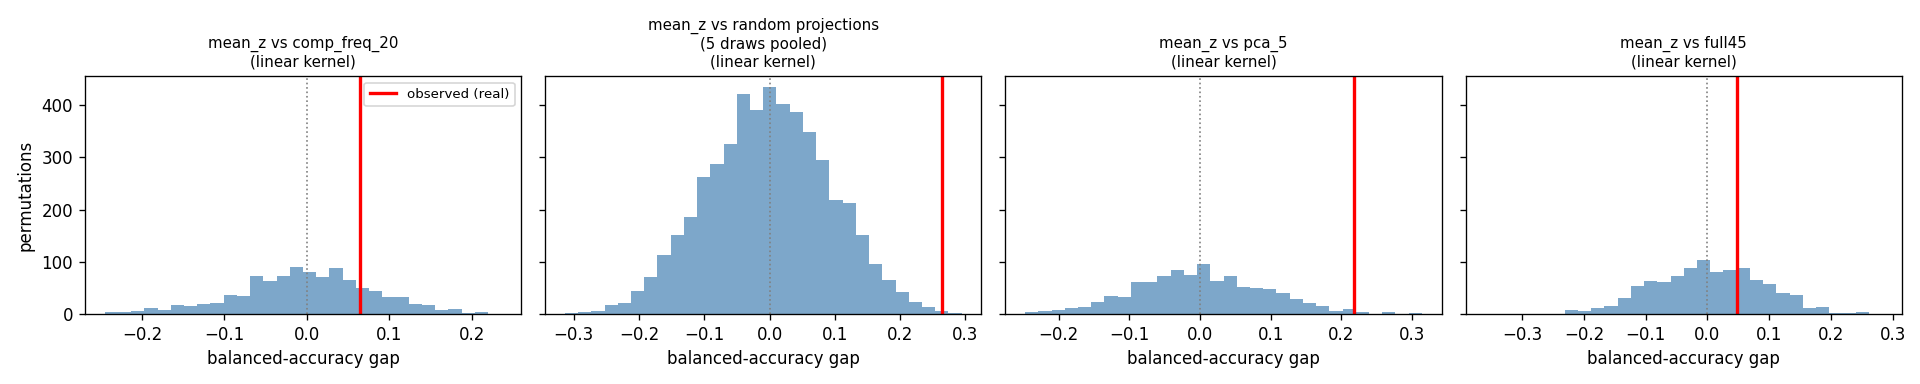

In [12]:
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
    pooled_null_linear = np.concatenate([null_gaps['linear'][rp] for rp in RAND_PROJ_NAMES])
    panels = [('comp_freq_20', null_gaps['linear']['comp_freq_20'],
              observed_gaps[('linear', 'comp_freq_20')], 'mean_z vs comp_freq_20'),
             ('rand_proj (5 draws pooled)', pooled_null_linear,
              np.mean([observed_gaps[('linear', rp)] for rp in RAND_PROJ_NAMES]),
              'mean_z vs random projections\n(5 draws pooled)'),
             ('pca_5', null_gaps['linear']['pca_5'],
              observed_gaps[('linear', 'pca_5')], 'mean_z vs pca_5'),
             ('full45', null_gaps['linear']['full45'],
              observed_gaps[('linear', 'full45')], 'mean_z vs full45')]
    for ax, (_, null_vals, obs_val, title) in zip(axes, panels):
        ax.hist(null_vals, bins=30, alpha=0.7, color='steelblue')
        ax.axvline(obs_val, color='red', lw=2, label='observed (real)')
        ax.axvline(0, color='gray', lw=1, ls=':')
        ax.set_title(f'{title}\n(linear kernel)', fontsize=9)
        ax.set_xlabel('balanced-accuracy gap')
    axes[0].set_ylabel('permutations')
    axes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{OUTDIR}/exp10_null_distributions.png', dpi=120)
    plt.show()
except ImportError:
    print('matplotlib not available -- see exp10_null_test.csv for the numbers')

## 7. Reading this`empirical_p_one_sided` is the fraction of the 1000 label permutations that produced a`mean_z` advantage at least as large as the one observed with the real labels. Smallvalues mean the real gap is well outside what this exact pipeline produces from purechance under the 43-group dependency structure, independent confirmation of theNadeau-Bengio and group-bootstrap intervals computed elsewhere. The pooled-random-projection row answers "does mean_z beat random projections in general", not "does itbeat this one arbitrary matrix".